# FaceRankNet — Master Colab Notebook
**Feature-Decomposed Facial Beauty Prediction**  
Dataset: SCUT-FBP5500 | Framework: PyTorch + DGL + MediaPipe

---
**Drive folder structure:**
```
MyDrive/Colab Notebooks/FaceRankNet/FaceRankNet/
  ├── config.py, preprocessing.py, dataset.py, model.py ...
  ├── run_colab.ipynb
  └── cache/   <- auto-created, persists across sessions
```
Run cells **in order**.

In [1]:
import sys, os

# Install DGL without touching torch or numpy (--no-deps)
!pip install dgl --no-deps -f https://data.dgl.ai/wheels/cu121/repo.html -q

# MediaPipe & CV
!pip install -q "mediapipe>=0.10" opencv-python-headless

# Scientific stack
!pip install -q pandas scikit-learn tqdm matplotlib scipy

# DGL dependency
!pip install -q torchdata

# Kaggle dataset downloader
!pip install -q kagglehub

print("Done. Continue to Cell 2.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.5/467.5 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.2 MB/s eta 0:00:00
Done. Continue to Cell 2.


In [2]:

import sys, types

if 'dgl.graphbolt' not in sys.modules:
    _gb = types.ModuleType('dgl.graphbolt')
    _gb.load_graphbolt = lambda: None
    sys.modules['dgl.graphbolt'] = _gb
    print('✓ DGL graphbolt pre-patched')

import dgl, torch
print(f'DGL     : {dgl.__version__}')
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

# Sanity check: confirm DGL can move a graph to GPU
if torch.cuda.is_available():
    _g = dgl.graph(([0], [1]))
    _g = _g.to('cuda')
    print('✓ DGL CUDA graph test passed')
else:
    print('⚠ No GPU detected — re-check Runtime -> Change runtime type -> T4 GPU')

✓ DGL graphbolt pre-patched
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


DGL backend not selected or invalid.  Assuming PyTorch for now.


DGL     : 2.1.0+cu121
PyTorch : 2.11.0+cu128
CUDA    : True
✓ DGL CUDA graph test passed


In [3]:
# ============================================================
# Cell 3 — Mount Drive, copy project files, (opsional) download dataset
#
# Kaggle download di-skip jika:
#   - TRAIN_CSV + TEST_CSV sudah ada di Drive  (gak perlu labels.txt), DAN
#   - Landmark caches sudah ada di Drive       (gak perlu images)
# CSV split di-skip jika TRAIN_CSV + TEST_CSV sudah ada.
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, pandas as pd
from sklearn.model_selection import train_test_split

DRIVE_ROOT   = '/content/drive/MyDrive/Colab Notebooks/FaceRankNet7'
PROJECT_ROOT = '/content/FaceRankNet'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(CACHE_DIR,    exist_ok=True)

# ── Copy .py files from Drive to runtime ────────────────────────────────────
copied = []
for fname in os.listdir(DRIVE_ROOT):
    if fname.endswith('.py'):
        shutil.copy(os.path.join(DRIVE_ROOT, fname), os.path.join(PROJECT_ROOT, fname))
        copied.append(fname)
sys.path.insert(0, PROJECT_ROOT)
print(f'Copied {len(copied)} .py files: {copied}')

# ── Define all paths ────────────────────────────────────────────────────────
TRAIN_CSV     = f'{DRIVE_ROOT}/train_labels.csv'
TEST_CSV      = f'{DRIVE_ROOT}/test_labels.csv'
CACHE_TRAIN   = f'{CACHE_DIR}/train_landmarks.pkl'
CACHE_TEST    = f'{CACHE_DIR}/test_landmarks.pkl'
AVG_FACE_PATH = f'{CACHE_DIR}/avg_face.npy'
PSEUDO_PATH   = f'{CACHE_DIR}/pseudo_labels.pkl'
CHECKPOINT    = f'{DRIVE_ROOT}/checkpoint_best.pt'

# ── Cache status check ───────────────────────────────────────────────────────
csvs_exist       = os.path.exists(TRAIN_CSV)   and os.path.exists(TEST_CSV)
landmarks_cached = os.path.exists(CACHE_TRAIN) and os.path.exists(CACHE_TEST)

print(f'\nCache status:')
print(f'  train_labels.csv    : {"✓" if os.path.exists(TRAIN_CSV) else "✗"}')
print(f'  test_labels.csv     : {"✓" if os.path.exists(TEST_CSV) else "✗"}')
print(f'  train_landmarks.pkl : {"✓" if os.path.exists(CACHE_TRAIN) else "✗"}')
print(f'  test_landmarks.pkl  : {"✓" if os.path.exists(CACHE_TEST) else "✗"}')
print(f'  avg_face.npy        : {"✓" if os.path.exists(AVG_FACE_PATH) else "✗"}')
print(f'  pseudo_labels.pkl   : {"✓" if os.path.exists(PSEUDO_PATH) else "✗"}')
print(f'  checkpoint_best.pt  : {"✓" if os.path.exists(CHECKPOINT) else "✗"}')

# ── Kaggle download (skip jika CSVs + landmark caches sudah ada) ─────────────
if csvs_exist and landmarks_cached:
    print('\n✓ CSVs dan landmark caches sudah ada — skip Kaggle download')
    IMAGE_DIR = None  # tidak dibutuhkan; Cell 4 juga akan skip extraction
else:
    import kagglehub
    print('\nDownloading SCUT-FBP5500 dari Kaggle ...')
    KAGGLE_PATH = kagglehub.dataset_download(
        'pranavchandane/scut-fbp5500-v2-facial-beauty-scores')
    print('Downloaded to:', KAGGLE_PATH)

    IMAGE_DIR   = os.path.join(KAGGLE_PATH, 'Images', 'Images')
    LABELS_FILE = os.path.join(KAGGLE_PATH, 'labels.txt')

    if not os.path.isdir(IMAGE_DIR):
        for root, _, files in os.walk(KAGGLE_PATH):
            if any(f.lower().endswith(('.jpg', '.png')) for f in files):
                IMAGE_DIR = root; break
    if not os.path.isfile(LABELS_FILE):
        for root, _, files in os.walk(KAGGLE_PATH):
            if 'labels.txt' in files:
                LABELS_FILE = os.path.join(root, 'labels.txt'); break

    n_img = len([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.jpg', '.png'))])
    print(f'Image dir: {IMAGE_DIR}  ({n_img} images)')

# ── Parse labels + train/test split (skip jika CSVs sudah ada) ───────────────
if not csvs_exist:
    df = pd.read_csv(LABELS_FILE, sep=' ', header=None, names=['Filename', 'Rating'])
    df['Ethnicity'] = df['Filename'].apply(
        lambda f: 'Asian' if f[0].upper() == 'A' else 'Caucasian')
    df['Gender'] = df['Filename'].apply(
        lambda f: 'Female' if f[1].upper() == 'F' else 'Male')
    print('Ethnicity dist:', df['Ethnicity'].value_counts().to_dict())
    print('Gender dist:',    df['Gender'].value_counts().to_dict())

    df['_b'] = df['Rating'].round(0).astype(int).clip(1, 5)
    train_df, test_df = train_test_split(
        df.drop(columns=['_b']), test_size=0.20, random_state=42, stratify=df['_b'])
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    train_df.to_csv(TRAIN_CSV, index=False)
    test_df.to_csv(TEST_CSV,   index=False)
    print(f'Train: {len(train_df)} | Test: {len(test_df)} — saved to Drive')
else:
    train_df = pd.read_csv(TRAIN_CSV)
    test_df  = pd.read_csv(TEST_CSV)
    # Backfill Ethnicity/Gender jika CSV di-save sebelum kolom ini ada
    _needs_resave = False
    for _df in [train_df, test_df]:
        if 'Ethnicity' not in _df.columns:
            _df['Ethnicity'] = _df['Filename'].apply(
                lambda f: 'Asian' if f[0].upper() == 'A' else 'Caucasian')
            _needs_resave = True
        if 'Gender' not in _df.columns:
            _df['Gender'] = _df['Filename'].apply(
                lambda f: 'Female' if f[1].upper() == 'F' else 'Male')
            _needs_resave = True
    if _needs_resave:
        train_df.to_csv(TRAIN_CSV, index=False)
        test_df.to_csv(TEST_CSV,   index=False)
        print('  ↳ Backfilled Ethnicity/Gender columns & re-saved CSVs to Drive')
    print(f'\n✓ CSVs loaded dari Drive: Train={len(train_df)} | Test={len(test_df)}')

print(f'\nAll paths ready. CHECKPOINT: {CHECKPOINT}')


Mounted at /content/drive
Copied 10 .py files: ['organ_indices.py', 'loss.py', 'train.py', 'dataset.py', 'preprocessing.py', 'config.py', 'model.py', 'evaluate.py', 'pseudo_labels.py', 'pseudo_label_diagnostic.py']

Cache status:
  train_labels.csv    : ✗
  test_labels.csv     : ✗
  train_landmarks.pkl : ✗
  test_landmarks.pkl  : ✗
  avg_face.npy        : ✗
  pseudo_labels.pkl   : ✗
  checkpoint_best.pt  : ✗



100%|██████████| 1.12G/1.12G [00:11<00:00, 102MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2
Image dir: /root/.cache/kagglehub/datasets/pranavchandane/scut-fbp5500-v2-facial-beauty-scores/versions/2/Images/Images  (5500 images)
Ethnicity dist: {'Asian': 4000, 'Caucasian': 1500}
Gender dist: {'Female': 2750, 'Male': 2750}
Train: 4400 | Test: 1100 — saved to Drive

All paths ready. CHECKPOINT: /content/drive/MyDrive/Colab Notebooks/FaceRankNet7/checkpoint_best.pt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
# ============================================================
# Cell 4 — Extract & cache landmarks  (~20-40 min, saved to Drive)
# Skips extraction jika cache .pkl sudah ada di Drive.
# ============================================================
import os, pickle
from preprocessing import preprocess_dataset

if os.path.exists(CACHE_TRAIN):
    print(f'✓ Cache ditemukan: {CACHE_TRAIN} — load saja (skip extraction)')
    with open(CACHE_TRAIN, 'rb') as f:
        train_coords = pickle.load(f)
else:
    print('Processing TRAIN set ...')
    train_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TRAIN_CSV, cache_path=CACHE_TRAIN)

if os.path.exists(CACHE_TEST):
    print(f'✓ Cache ditemukan: {CACHE_TEST} — load saja (skip extraction)')
    with open(CACHE_TEST, 'rb') as f:
        test_coords = pickle.load(f)
else:
    print('\nProcessing TEST set ...')
    test_coords = preprocess_dataset(
        image_dir=IMAGE_DIR, csv_path=TEST_CSV, cache_path=CACHE_TEST)

print(f'✓ Train: {len(train_coords)} | Test: {len(test_coords)} faces')


Processing TRAIN set ...


Extracting landmarks: 100%|██████████| 4400/4400 [01:32<00:00, 47.35img/s]



Processing TEST set ...


Extracting landmarks: 100%|██████████| 1100/1100 [00:22<00:00, 49.17img/s]

✓ Train: 4400 | Test: 1100 faces


In [5]:
# ============================================================
# Cell 5 — Pseudo-Labels via beauty-axis projection (per-ethnicity H1)
# Skips compute jika avg_face + pseudo_labels sudah ada di Drive.
# ============================================================
import os, pickle, numpy as np, pandas as pd
from pseudo_labels import (
    compute_universal_average_face,
    compute_beauty_prototype,
    compute_ethnicity_avg_faces,
    compute_all_pseudo_labels_beauty_axis,
    validate_pseudo_label_quality,
    save_avg_face, save_pseudo_labels,
    load_pseudo_labels, load_avg_face,
)

train_df_loaded = pd.read_csv(TRAIN_CSV)
train_filenames = train_df_loaded["Filename"].tolist()
holistic_map    = dict(zip(train_df_loaded["Filename"], train_df_loaded["Rating"].astype(float)))
ethnicity_map   = dict(zip(train_df_loaded["Filename"], train_df_loaded["Ethnicity"]))

cache_hit = os.path.exists(AVG_FACE_PATH) and os.path.exists(PSEUDO_PATH)

if cache_hit:
    print('✓ Caches found — loading from Drive (skip compute)')
    population_mean = load_avg_face(AVG_FACE_PATH)
    pseudo_labels   = load_pseudo_labels(PSEUDO_PATH)
else:
    if 'train_coords' not in globals():
        with open(CACHE_TRAIN, 'rb') as f:
            train_coords = pickle.load(f)

    train_coords_list  = [train_coords[f] for f in train_filenames if f in train_coords]
    train_ratings_list = [holistic_map[f]  for f in train_filenames if f in train_coords]

    population_mean  = compute_universal_average_face(train_coords_list)
    beauty_prototype = compute_beauty_prototype(train_coords_list, train_ratings_list, top_k_pct=0.30)

    pop_mean_eth_map     = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map, holistic_ratings=None)
    beauty_proto_eth_map = compute_ethnicity_avg_faces(
        train_coords, train_filenames, ethnicity_map,
        holistic_ratings=holistic_map, top_k_pct=0.30)

    print('Computing beauty-axis pseudo-labels (per-ethnicity) ...')
    pseudo_labels = compute_all_pseudo_labels_beauty_axis(
        coords_cache=train_coords,
        train_filenames=train_filenames,
        population_mean=population_mean,
        beauty_prototype=beauty_prototype,
        population_mean_map=pop_mean_eth_map,
        beauty_prototype_map=beauty_proto_eth_map,
        ethnicity_map=ethnicity_map,
    )

    save_avg_face(population_mean, AVG_FACE_PATH)
    save_pseudo_labels(pseudo_labels, PSEUDO_PATH)
    print(f'✓ Saved: {AVG_FACE_PATH}')
    print(f'         {PSEUDO_PATH}')

rho = validate_pseudo_label_quality(pseudo_labels, holistic_map)
print(f'\nSpearman rho (beauty-axis): {rho:.4f}  (target > 0.2)')

print()
for sample in ["CF137.jpg", "CF581.jpg", "AF1859.jpg", "AF549.jpg"]:
    if sample in pseudo_labels:
        organs = pseudo_labels[sample]
        mean_score = sum(organs.values()) / len(organs)
        print(f'{sample}  rating={holistic_map.get(sample, "?"):.3f}  mean_pseudo={mean_score:.3f}')
        for organ, score in organs.items():
            print(f'  {organ:<12}: {score:.3f}')


Computing beauty-axis pseudo-labels (per-ethnicity) ...


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:00<00:00, 6834.89face/s]


✓ Saved: /content/drive/MyDrive/Colab Notebooks/FaceRankNet7/cache/avg_face.npy
         /content/drive/MyDrive/Colab Notebooks/FaceRankNet7/cache/pseudo_labels.pkl

Spearman rho (beauty-axis): 0.5740  (target > 0.2)

CF137.jpg  rating=2.933  mean_pseudo=4.227
  left_eye    : 2.355
  right_eye   : 4.991
  nose        : 4.934
  mouth       : 3.951
  jawline     : 4.904
CF581.jpg  rating=4.450  mean_pseudo=3.642
  left_eye    : 1.025
  right_eye   : 4.828
  nose        : 4.704
  mouth       : 3.807
  jawline     : 3.845
AF1859.jpg  rating=1.850  mean_pseudo=3.023
  left_eye    : 3.128
  right_eye   : 2.765
  nose        : 3.427
  mouth       : 2.660
  jawline     : 3.134
AF549.jpg  rating=2.183  mean_pseudo=3.339
  left_eye    : 3.631
  right_eye   : 2.896
  nose        : 3.515
  mouth       : 3.112
  jawline     : 3.538



[1/4] axis_eth (existing baseline) ...


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:00<00:00, 6573.89face/s]



[2a/4] rmse_eth (existing baseline — uses per-eth BEAUTY PROTOTYPE) ...


Pass 2 — pseudo scores: 100%|██████████| 4400/4400 [00:00<00:00, 6288.13face/s]



[2b/4] rmse_eth_popmean (per-eth POPULATION MEAN — sanity-check target) ...


...


[3/4] local_axis sweep at bandwidths=[0.3, 0.5, 0.8, 1.2, 2.0] (+ sanity bw=100.0) ...


local_axis — projections [Asian, bw=100.0]: 100%|██████████| 3178/3178 [00:11<00:00, 268.15face/s]



[4/4] local_rmse sweep at bandwidths=[0.3, 0.5, 0.8, 1.2, 2.0] (+ sanity bw=100.0) ...


local_rmse — distances [Asian, bw=100.0]: 100%|██████████| 3178/3178 [00:03<00:00, 895.60face/s]




=========== QUALITY REPORTS ===========
  Pseudo-label quality — method: axis_eth   (n=4400)
------------------------------------------------------------------------
  Global Spearman ρ = +0.5740
------------------------------------------------------------------------
  Per organ:
    jawline      +0.5593
    left_eye     +0.4472
    mouth        +0.5668
    nose         +0.5833
    right_eye    +0.4773
------------------------------------------------------------------------
  Per ethnicity:
    Caucasian    +0.5582   n=1222
    Asian        +0.5772   n=3178
------------------------------------------------------------------------
  Per gender:
    Female       +0.5745   n=2209
    Male         +0.5282   n=2191
------------------------------------------------------------------------
  Per rating-bucket (the bit that matters most for the tails):
    Jelek    -0.0910   n=188
    Avg      +0.2306   n=2412
    Mid      +0.2653   n=1294
    Cantik   +0.0258   n=506
  Pseudo-label quality —

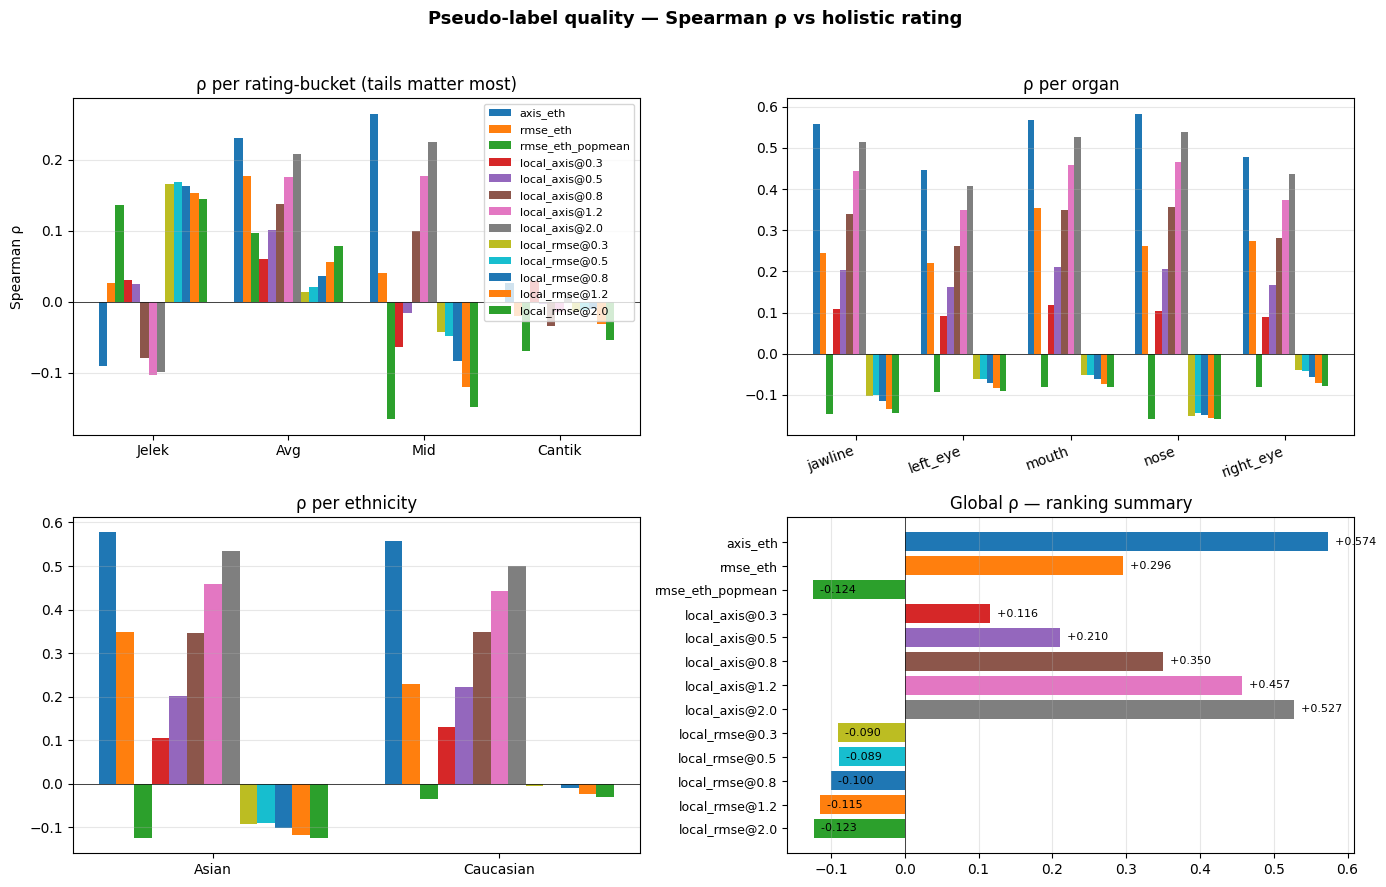

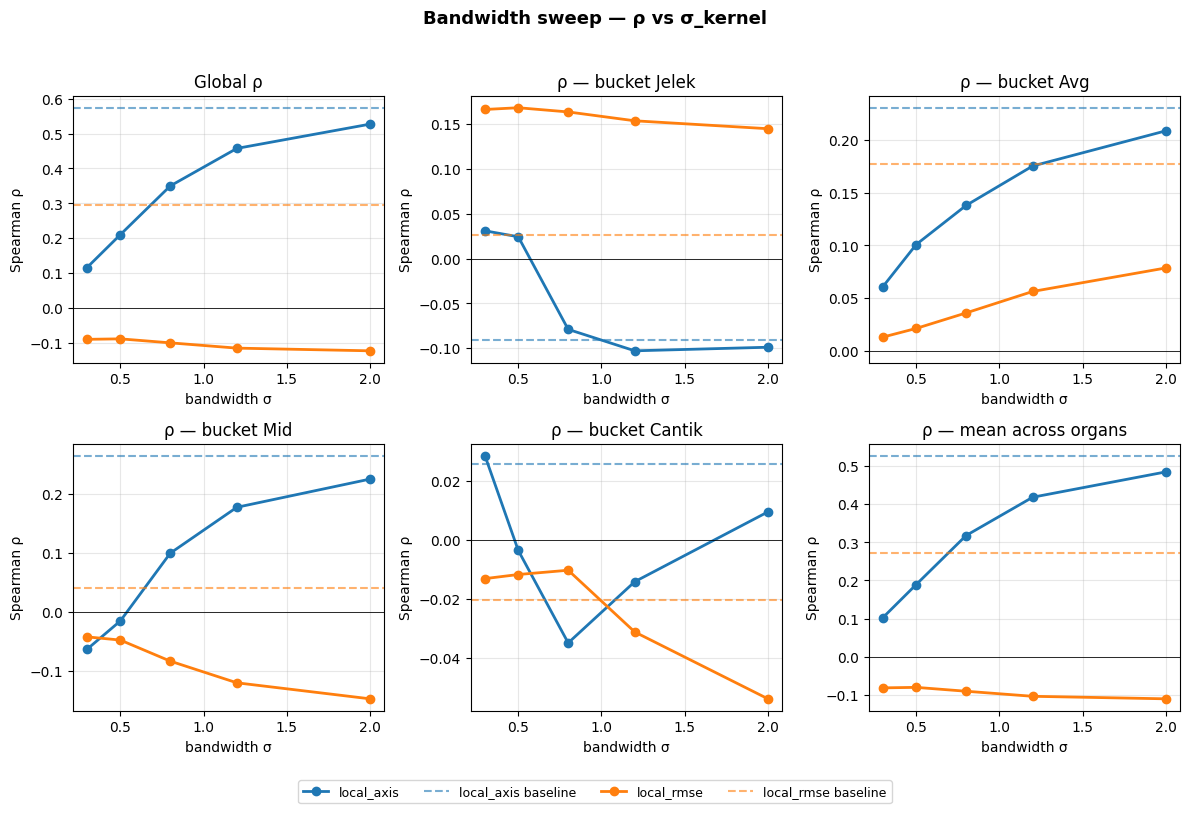

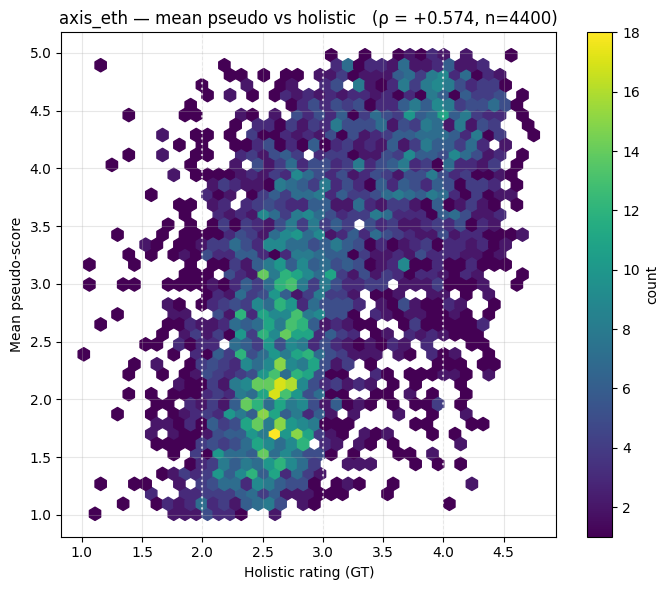

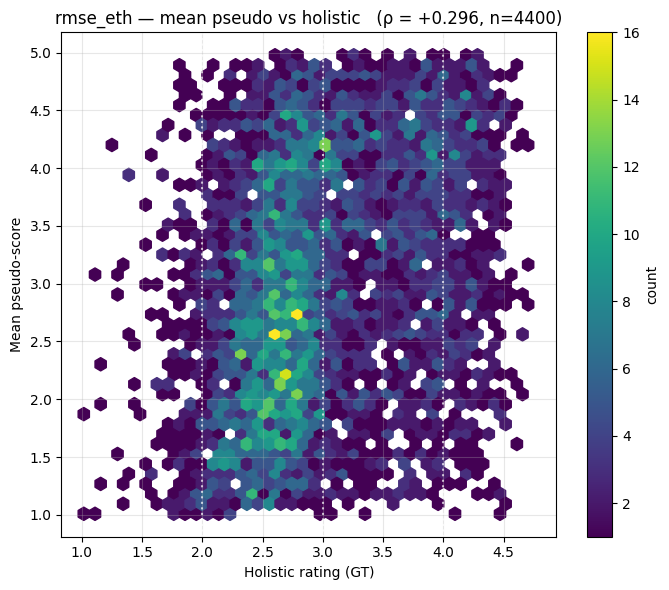

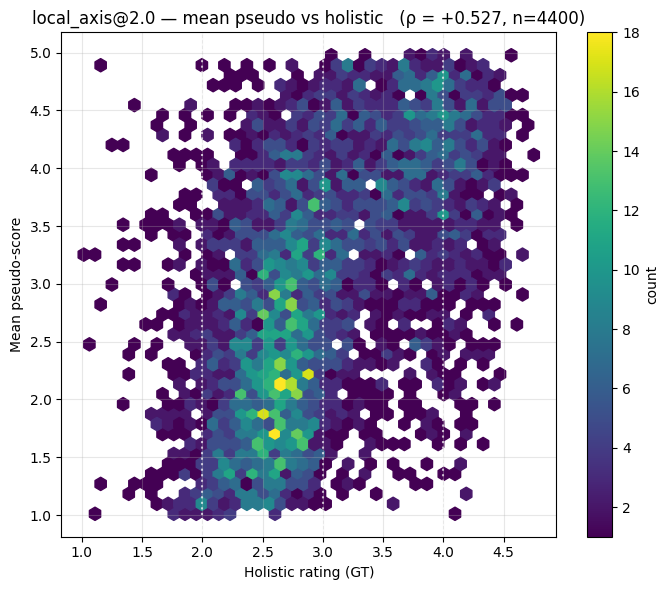

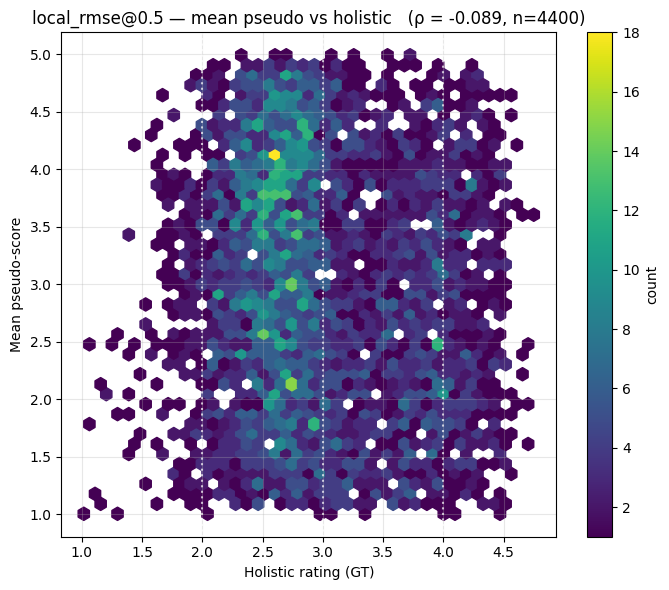


=========== SUCCESS-CRITERIA VERDICT ===========
Best local_axis bandwidth : 2.0
Best local_rmse bandwidth : 0.5

# 1) Locality (does kernel weighting help RMSE in the tails?)
   bucket Jelek : rmse_eth=+0.0267  ->  local_rmse@0.5=+0.1683  (delta = +0.1416)
   bucket Cantik: rmse_eth=-0.0202  ->  local_rmse@0.5=-0.0117  (delta = +0.0086)

# 2) Direction (does axis beat RMSE at the same locality)?
   global rho     : local_axis=+0.5270  vs local_rmse=-0.0886  (delta = +0.6156)
   bucket Jelek : local_axis=-0.0989  vs local_rmse=+0.1683  (delta = -0.2672)
   bucket Cantik: local_axis=+0.0096  vs local_rmse=-0.0117  (delta = +0.0212)

# 3) Net: does local_axis improve tails without hurting Avg/Mid > 0.05?
   bucket Jelek : axis_eth=-0.0910  ->  local_axis@2.0=-0.0989  (delta = -0.0079)
   bucket Avg   : axis_eth=+0.2306  ->  local_axis@2.0=+0.2087  (delta = -0.0219)
   bucket Mid   : axis_eth=+0.2653  ->  local_axis@2.0=+0.2256  (delta = -0.0397)
   bucket Cantik: axis_eth=+0.0258  ->  l

In [6]:
# ============================================================
# Cell 5b — LOCAL beauty axis / LOCAL RMSE  diagnostic sweep
# Branch: experiment/local-beauty-axis
#
# Compares 4 pseudo-label variants on the same train split:
#   - axis_eth      (existing global+directional baseline, per-eth)
#   - rmse_eth      (existing global+isotropic  baseline, per-eth)
#   - local_axis    (NEW: kernel-weighted local axis, swept over bandwidth)
#   - local_rmse    (NEW: kernel-weighted local RMSE, swept over bandwidth)
#
# Outputs Spearman rho per-bucket / per-organ / per-eth / per-gender for
# every combination, plus comparison plots. Does NOT touch the model.
# ============================================================
import os, pickle, numpy as np, pandas as pd
from pathlib import Path

from pseudo_labels import (
    compute_universal_average_face,
    compute_beauty_prototype,
    compute_ethnicity_avg_faces,
    compute_all_pseudo_labels,                  # rmse_eth (with per-eth maps)
    compute_all_pseudo_labels_beauty_axis,      # axis_eth
    compute_all_pseudo_labels_local_axis,       # NEW
    compute_all_pseudo_labels_local_rmse,       # NEW
)
from pseudo_label_diagnostic import (
    pseudo_label_quality_report,
    build_comparison_table,
    plot_quality_report,
    plot_bandwidth_sweep,
    plot_pseudo_vs_holistic,
)

# ---- 1. Load train coords + maps (same as Cell 5) -------------------------
train_df_loaded = pd.read_csv(TRAIN_CSV)
train_filenames = train_df_loaded["Filename"].tolist()
holistic_map    = dict(zip(train_df_loaded["Filename"], train_df_loaded["Rating"].astype(float)))
ethnicity_map   = dict(zip(train_df_loaded["Filename"], train_df_loaded["Ethnicity"]))

if 'train_coords' not in globals():
    with open(CACHE_TRAIN, 'rb') as f:
        train_coords = pickle.load(f)

train_coords_list  = [train_coords[f] for f in train_filenames if f in train_coords]
train_ratings_list = [holistic_map[f]  for f in train_filenames if f in train_coords]

population_mean  = compute_universal_average_face(train_coords_list)
beauty_prototype = compute_beauty_prototype(train_coords_list, train_ratings_list, top_k_pct=0.30)

pop_mean_eth_map     = compute_ethnicity_avg_faces(
    train_coords, train_filenames, ethnicity_map, holistic_ratings=None)
beauty_proto_eth_map = compute_ethnicity_avg_faces(
    train_coords, train_filenames, ethnicity_map,
    holistic_ratings=holistic_map, top_k_pct=0.30)

# ---- 2. Existing baselines -----------------------------------------------
print("\n[1/4] axis_eth (existing baseline) ...")
pl_axis_eth = compute_all_pseudo_labels_beauty_axis(
    coords_cache=train_coords,
    train_filenames=train_filenames,
    population_mean=population_mean,
    beauty_prototype=beauty_prototype,
    population_mean_map=pop_mean_eth_map,
    beauty_prototype_map=beauty_proto_eth_map,
    ethnicity_map=ethnicity_map,
)
print("\n[2a/4] rmse_eth (existing baseline — uses per-eth BEAUTY PROTOTYPE) ...")
pl_rmse_eth = compute_all_pseudo_labels(
    coords_cache=train_coords,
    avg_face=population_mean,
    train_filenames=train_filenames,
    avg_face_map=beauty_proto_eth_map,
    ethnicity_map=ethnicity_map,
)

# NOTE on the sanity check:
#   - local_rmse @ bw -> infinity  uses kernel weights that flatten out, so
#     its reference -> per-ethnicity POPULATION MEAN (not the top-30% proto).
#   - rmse_eth (above) uses the top-30% BEAUTY PROTOTYPE as reference, so it
#     does NOT converge to local_rmse@inf. We compute a second rmse baseline
#     against the per-eth population mean (`rmse_eth_popmean`) so the
#     convergence test has a meaningful target.
print("\n[2b/4] rmse_eth_popmean (per-eth POPULATION MEAN — sanity-check target) ...")
pl_rmse_eth_popmean = compute_all_pseudo_labels(
    coords_cache=train_coords,
    avg_face=population_mean,
    train_filenames=train_filenames,
    avg_face_map=pop_mean_eth_map,
    ethnicity_map=ethnicity_map,
)

# ---- 3. NEW variants × bandwidth sweep -----------------------------------
BANDWIDTHS = [0.3, 0.5, 0.8, 1.2, 2.0]
SANITY_BANDWIDTH = 100.0  # convergence check: must approximate the global baseline
DELTA = 0.5               # local-axis offset on the rating axis

print(f"\n[3/4] local_axis sweep at bandwidths={BANDWIDTHS} (+ sanity bw={SANITY_BANDWIDTH}) ...")
pl_local_axis = {}
for bw in BANDWIDTHS + [SANITY_BANDWIDTH]:
    pl_local_axis[bw] = compute_all_pseudo_labels_local_axis(
        coords_cache=train_coords,
        train_filenames=train_filenames,
        holistic_ratings=holistic_map,
        ethnicity_map=ethnicity_map,
        bandwidth=bw,
        delta=DELTA,
    )

print(f"\n[4/4] local_rmse sweep at bandwidths={BANDWIDTHS} (+ sanity bw={SANITY_BANDWIDTH}) ...")
pl_local_rmse = {}
for bw in BANDWIDTHS + [SANITY_BANDWIDTH]:
    pl_local_rmse[bw] = compute_all_pseudo_labels_local_rmse(
        coords_cache=train_coords,
        train_filenames=train_filenames,
        holistic_ratings=holistic_map,
        ethnicity_map=ethnicity_map,
        bandwidth=bw,
    )

# ---- 4. Quality reports + comparison table -------------------------------
print("\n\n=========== QUALITY REPORTS ===========")
reports = []
reports.append(pseudo_label_quality_report(pl_axis_eth, holistic_map, ethnicity_map, method_name="axis_eth"))
reports.append(pseudo_label_quality_report(pl_rmse_eth, holistic_map, ethnicity_map, method_name="rmse_eth"))
reports.append(pseudo_label_quality_report(pl_rmse_eth_popmean, holistic_map, ethnicity_map, method_name="rmse_eth_popmean"))
for bw in BANDWIDTHS:
    reports.append(pseudo_label_quality_report(
        pl_local_axis[bw], holistic_map, ethnicity_map,
        method_name=f"local_axis@{bw}"))
for bw in BANDWIDTHS:
    reports.append(pseudo_label_quality_report(
        pl_local_rmse[bw], holistic_map, ethnicity_map,
        method_name=f"local_rmse@{bw}"))

# Sanity convergence (separate, not in main table)
sanity_axis = pseudo_label_quality_report(
    pl_local_axis[SANITY_BANDWIDTH], holistic_map, ethnicity_map,
    method_name=f"local_axis@{SANITY_BANDWIDTH}", verbose=False)
sanity_rmse = pseudo_label_quality_report(
    pl_local_rmse[SANITY_BANDWIDTH], holistic_map, ethnicity_map,
    method_name=f"local_rmse@{SANITY_BANDWIDTH}", verbose=False)

print("\n=========== SANITY: bandwidth -> infinity ===========")
print("(local_axis@inf -> axis_eth ; local_rmse@inf -> rmse_eth_popmean )")
print(f"axis_eth         global rho           = {reports[0]['global_rho']:+.4f}")
print(f"local_axis @ bw={SANITY_BANDWIDTH:>4} global rho     = {sanity_axis['global_rho']:+.4f}")
print(f"  delta = {abs(sanity_axis['global_rho'] - reports[0]['global_rho']):.4f}   "
      f"(target < 0.02)")
print(f"rmse_eth_popmean global rho           = {reports[2]['global_rho']:+.4f}")
print(f"local_rmse @ bw={SANITY_BANDWIDTH:>4} global rho     = {sanity_rmse['global_rho']:+.4f}")
print(f"  delta = {abs(sanity_rmse['global_rho'] - reports[2]['global_rho']):.4f}   "
      f"(target < 0.02)")

# Comparison table
print("\n=========== COMPARISON TABLE (sorted by global rho desc) ===========")
df_cmp = build_comparison_table(reports)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(df_cmp.to_string(index=False, float_format=lambda x: f"{x:+.4f}"))

# Persist CSV for later inspection
OUT_DIR = Path("/content") / "local_beauty_axis_diagnostic"
OUT_DIR.mkdir(parents=True, exist_ok=True)
df_cmp.to_csv(OUT_DIR / "comparison_table.csv", index=False)
print(f"\nSaved table -> {OUT_DIR/'comparison_table.csv'}")

# ---- 5. Visualizations ---------------------------------------------------
import matplotlib
matplotlib.use("Agg") if "DISPLAY" not in os.environ and not hasattr(__builtins__, "get_ipython") else None
import matplotlib.pyplot as plt

# (a) Side-by-side bar charts of every method on bucket / organ / eth / global
plot_quality_report(reports, out_path=OUT_DIR / "quality_report_bars.png")
plt.show()

# (b) Bandwidth sweep curves (one line per variant per panel)
N_BASE = 3  # axis_eth, rmse_eth, rmse_eth_popmean
sweep_reports = {
    "local_axis":  {bw: reports[N_BASE + i] for i, bw in enumerate(BANDWIDTHS)},
    "local_rmse":  {bw: reports[N_BASE + len(BANDWIDTHS) + i] for i, bw in enumerate(BANDWIDTHS)},
}
# attach baselines as flat dashed lines (sentinel bandwidth = -1)
sweep_reports["local_axis"][-1.0] = reports[0]   # axis_eth
sweep_reports["local_rmse"][-1.0] = reports[1]   # rmse_eth (production)

plot_bandwidth_sweep(sweep_reports, out_path=OUT_DIR / "bandwidth_sweep.png")
plt.show()

# (c) Pseudo-vs-holistic hexbins for the 4 reference methods + best local_axis
best_local_axis_bw = max(BANDWIDTHS,
    key=lambda bw: sweep_reports["local_axis"][bw]["global_rho"])
best_local_rmse_bw = max(BANDWIDTHS,
    key=lambda bw: sweep_reports["local_rmse"][bw]["global_rho"])

plot_pseudo_vs_holistic(pl_axis_eth, holistic_map,
    method_name="axis_eth", out_path=OUT_DIR / "scatter_axis_eth.png"); plt.show()
plot_pseudo_vs_holistic(pl_rmse_eth, holistic_map,
    method_name="rmse_eth", out_path=OUT_DIR / "scatter_rmse_eth.png"); plt.show()
plot_pseudo_vs_holistic(pl_local_axis[best_local_axis_bw], holistic_map,
    method_name=f"local_axis@{best_local_axis_bw}",
    out_path=OUT_DIR / f"scatter_local_axis_{best_local_axis_bw}.png"); plt.show()
plot_pseudo_vs_holistic(pl_local_rmse[best_local_rmse_bw], holistic_map,
    method_name=f"local_rmse@{best_local_rmse_bw}",
    out_path=OUT_DIR / f"scatter_local_rmse_{best_local_rmse_bw}.png"); plt.show()

# ---- 6. Verdict on the three success criteria ----------------------------
def _pb(r, b): return r["per_bucket"][b]["rho"]

best_axis_r  = sweep_reports["local_axis"][best_local_axis_bw]
best_rmse_r  = sweep_reports["local_rmse"][best_local_rmse_bw]
axis_eth_r   = reports[0]
rmse_eth_r   = reports[1]

print("\n=========== SUCCESS-CRITERIA VERDICT ===========")
print(f"Best local_axis bandwidth : {best_local_axis_bw}")
print(f"Best local_rmse bandwidth : {best_local_rmse_bw}\n")

print("# 1) Locality (does kernel weighting help RMSE in the tails?)")
for b in ["Jelek", "Cantik"]:
    d_local = _pb(best_rmse_r, b)
    d_glob  = _pb(rmse_eth_r,  b)
    print(f"   bucket {b:<6}: rmse_eth={d_glob:+.4f}  ->  "
          f"local_rmse@{best_local_rmse_bw}={d_local:+.4f}  "
          f"(delta = {d_local - d_glob:+.4f})")

print("\n# 2) Direction (does axis beat RMSE at the same locality)?")
print(f"   global rho     : local_axis={best_axis_r['global_rho']:+.4f}  "
      f"vs local_rmse={best_rmse_r['global_rho']:+.4f}  "
      f"(delta = {best_axis_r['global_rho'] - best_rmse_r['global_rho']:+.4f})")
for b in ["Jelek", "Cantik"]:
    print(f"   bucket {b:<6}: local_axis={_pb(best_axis_r,b):+.4f}  "
          f"vs local_rmse={_pb(best_rmse_r,b):+.4f}  "
          f"(delta = {_pb(best_axis_r,b) - _pb(best_rmse_r,b):+.4f})")

print("\n# 3) Net: does local_axis improve tails without hurting Avg/Mid > 0.05?")
for b in ["Jelek", "Avg", "Mid", "Cantik"]:
    d_local = _pb(best_axis_r, b)
    d_glob  = _pb(axis_eth_r,  b)
    flag = ""
    if b in ("Avg", "Mid") and d_local + 0.05 < d_glob:
        flag = "  <- regression > 0.05 (criterion #3 FAIL)"
    print(f"   bucket {b:<6}: axis_eth={d_glob:+.4f}  ->  "
          f"local_axis@{best_local_axis_bw}={d_local:+.4f}  "
          f"(delta = {d_local - d_glob:+.4f}){flag}")
print("\nPlots + table saved to:", OUT_DIR)
